
Classification Accuracy: 68.00%


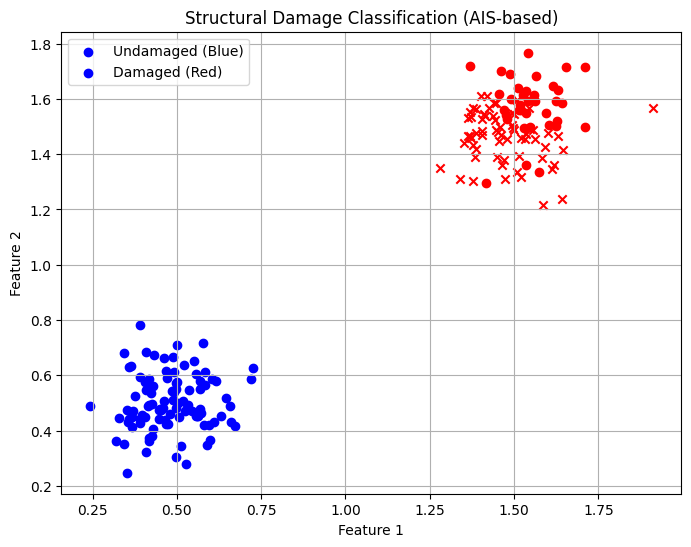

In [1]:
import numpy as np
import random
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Step 1: Generate synthetic dataset
def generate_dataset(samples=100, features=5):
    """
    Create synthetic feature vectors for 'undamaged' and 'damaged' structure conditions.
    """
    # Undamaged: normally distributed around 0.5
    undamaged = np.random.normal(loc=0.5, scale=0.1, size=(samples//2, features))
    
    # Damaged: normally distributed around 1.5
    damaged = np.random.normal(loc=1.5, scale=0.1, size=(samples//2, features))
    
    # Combine and assign labels (0 = undamaged, 1 = damaged)
    X = np.vstack((undamaged, damaged))
    y = np.array([0] * (samples // 2) + [1] * (samples // 2))
    
    return X, y

# Step 2: Generate detectors (Negative Selection Algorithm)
def generate_detectors(non_self_data, num_detectors=50, r=0.5):
    """
    Generate detectors that do NOT match the self data (undamaged).
    """
    detectors = []
    
    while len(detectors) < num_detectors:
        # Generate a random detector in feature space
        candidate = np.random.uniform(low=0, high=2, size=non_self_data.shape[1])
        
        match = False
        for data in non_self_data:
            # Calculate Euclidean distance
            if np.linalg.norm(candidate - data) < r:
                match = True
                break
        
        if not match:
            detectors.append(candidate)
    
    return np.array(detectors)

# Step 3: Classification using detectors
def classify(instance, detectors, r=0.5):
    """
    Classify input vector based on match with detectors.
    """
    for detector in detectors:
        if np.linalg.norm(detector - instance) < r:
            return 1  # Classified as damaged
    return 0  # Classified as undamaged

# Step 4: Main function
def main():
    # Generate data
    X, y = generate_dataset(samples=200, features=5)
    
    # Train on self (undamaged) data only
    self_data = X[y == 0]
    
    # Generate detectors that avoid matching self_data
    detectors = generate_detectors(self_data, num_detectors=100, r=0.4)
    
    # Predict labels for all data points
    y_pred = [classify(x, detectors, r=0.4) for x in X]
    
    # Evaluate classification accuracy
    accuracy = accuracy_score(y, y_pred)
    print(f"\nClassification Accuracy: {accuracy * 100:.2f}%")

    # Optional: Visualize first two features
    plt.figure(figsize=(8, 6))
    for i in range(len(X)):
        color = 'blue' if y[i] == 0 else 'red'
        marker = 'o' if y_pred[i] == y[i] else 'x'  # Mark misclassified points
        plt.scatter(X[i][0], X[i][1], color=color, marker=marker)
    
    plt.title('Structural Damage Classification (AIS-based)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.legend(['Undamaged (Blue)', 'Damaged (Red)'])
    plt.show()

# Run the main program
if __name__ == "__main__":
    main()
